In [ ]:
import subprocess, sys, os, glob, textwrap, traceback
import numpy as np, torch
from PIL import Image
import matplotlib.pyplot as plt

def pip_install(*pkgs):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *pkgs], check=True)

pip_install("qai_hub_models")

OUT_DIR = "/content/qaihm_out"; os.makedirs(OUT_DIR, exist_ok=True)
torch.set_grad_enabled(False)

def to_nchw(value):
    arr = value[0] if isinstance(value, (list, tuple)) else value
    t = torch.from_numpy(np.asarray(arr, dtype=np.float32))
    if t.ndim == 3:
        t = t.unsqueeze(0)
    if t.ndim == 4 and t.shape[1] != 3 and t.shape[-1] == 3:
        t = t.permute(0, 3, 1, 2).contiguous()
    return t

In [ ]:
import pkgutil, qai_hub_models.models as _m
model_ids = sorted(n for _, n, p in pkgutil.iter_modules(_m.__path__)
                   if p and not n.startswith("_"))
print(f">>> {len(model_ids)} models available. First 40:\n")
print(textwrap.fill(", ".join(model_ids[:40]), 100), "\n")

from qai_hub_models.models.mobilenet_v2 import Model as MobileNetV2
model = MobileNetV2.from_pretrained().eval()
spec = model.get_input_spec()
input_name = list(spec.keys())[0]
print(">>> Input:", input_name, spec[input_name].shape, spec[input_name].dtype)

from torchvision.models import MobileNet_V2_Weights
IMAGENET_CLASSES = MobileNet_V2_Weights.IMAGENET1K_V1.meta["categories"]

def top5(logits):
    if logits.ndim == 1: logits = logits.unsqueeze(0)
    probs = torch.softmax(logits, dim=1)[0]
    conf, idx = probs.topk(5)
    return [(IMAGENET_CLASSES[i], float(c)) for c, i in zip(conf, idx)]

In [ ]:
sample = model.sample_inputs()
x = to_nchw(sample[input_name])
print(">>> fed tensor shape:", tuple(x.shape))
print("\n>>> Top-5 for the built-in sample input:")
for label, conf in top5(model(x)):
    print(f"    {conf:6.2%}  {label}")

from torchvision import transforms
preprocess = transforms.Compose([
    transforms.Resize(256), transforms.CenterCrop(224), transforms.ToTensor(),
])
img = None
try:
    import urllib.request
    p = os.path.join(OUT_DIR, "input.jpg")
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/pytorch/hub/master/images/dog.jpg", p)
    img = Image.open(p).convert("RGB")
except Exception as e:
    print(">>> photo download skipped:", e)

if img is not None:
    preds = top5(model(preprocess(img).unsqueeze(0)))
    print("\n>>> Top-5 for the downloaded photo:")
    for label, conf in preds: print(f"    {conf:6.2%}  {label}")
    plt.figure(figsize=(5,5)); plt.imshow(img); plt.axis("off")
    plt.title(f"{preds[0][0]}  ({preds[0][1]:.1%})"); plt.show()

In [ ]:
def run_demo(module, extra=None, timeout=900):
    cmd = [sys.executable, "-m", module, "--eval-mode", "fp",
           "--output-dir", OUT_DIR] + (extra or [])
    print(f"\n>>> {' '.join(cmd)}")
    try:
        r = subprocess.run(cmd, capture_output=True, text=True, timeout=timeout)
        print("\n".join((r.stdout + r.stderr).strip().splitlines()[-25:]))
    except Exception as e:
        print(">>> demo skipped:", e)

run_demo("qai_hub_models.models.mobilenet_v2.demo")

try:
    pip_install("qai_hub_models[yolov7]")
    run_demo("qai_hub_models.models.yolov7.demo")
    imgs = sorted(glob.glob(OUT_DIR + "/*.png") + glob.glob(OUT_DIR + "/*.jpg"),
                  key=os.path.getmtime)
    if imgs:
        plt.figure(figsize=(9,9)); plt.imshow(Image.open(imgs[-1]).convert("RGB"))
        plt.axis("off"); plt.title("YOLOv7 detections"); plt.show()
    else:
        print(">>> no output image found (results may have printed instead).")
except Exception:
    print(">>> YOLOv7 section skipped:\n", traceback.format_exc())

>>> 189 models available. First 40:

act, aotgan, baichuan2_7b, beit, bevdet, bevfusion_det, cavaface, centernet_2d, centernet_pose,
centerpoint, conditional_detr_resnet50, controlnet_canny, convnext_base, convnext_tiny, crestereo,
cvt, ddcolor, ddrnet23_slim, deepbox, deeplab_xception, deeplabv3_plus_mobilenet, densenet121,
depth_anything, depth_anything_v2, depth_anything_v3, detectron2_detection, detr_resnet101,
detr_resnet101_dc5, detr_resnet50, detr_resnet50_dc5, distil_bert_base_uncased_hf, distil_whisper,
dla102x, dncnn, easyocr, edgetam, efficientformer, efficientnet_b0, efficientnet_b4,
efficientnet_v2_s 

>>> Input: image_tensor (1, 3, 224, 224) float32
>>> fed tensor shape: (1, 3, 224, 224)

>>> Top-5 for the built-in sample input:
    74.96%  Samoyed
     9.72%  Pomeranian
     7.83%  Arctic fox
     3.49%  keeshond
     1.11%  white wolf

>>> Top-5 for the downloaded photo:
    74.96%  Samoyed
     9.72%  Pomeranian
     7.83%  Arctic fox
     3.49%  keeshond
     1.11%  w

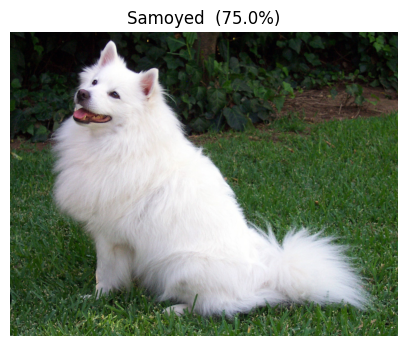


>>> /usr/bin/python3 -m qai_hub_models.models.mobilenet_v2.demo --eval-mode fp --output-dir /content/qaihm_out
usage: demo.py [-h] [--weights WEIGHTS] [--eval-mode {fp,on-device}]
               [--hub-model-id HUB_MODEL_ID]
               [--device DEVICE_STR | --chipset CHIPSET]
               [--device-os DEVICE_OS] [--inference-options INFERENCE_OPTIONS]
               [--target-runtime {tflite, qnn_dlc, qnn_context_binary, onnx, precompiled_qnn_onnx, genie, voice_ai}]
               [--precision {w8a16, w8a8, float} | --quantize [{w8a16, w8a8}]]
               [--image IMAGE]
demo.py: error: unrecognized arguments: --output-dir /content/qaihm_out

>>> /usr/bin/python3 -m qai_hub_models.models.yolov7.demo --eval-mode fp --output-dir /content/qaihm_out
yolov7 requires external repo https://github.com/WongKinYiu/yolov7. Ok to clone? [Y/n] Cloning https://github.com/WongKinYiu/yolov7 (84932d70) for yolov7...
Done

Fusing layers... 
Model Loaded
Saving image to /content/qaihm_out/yolo

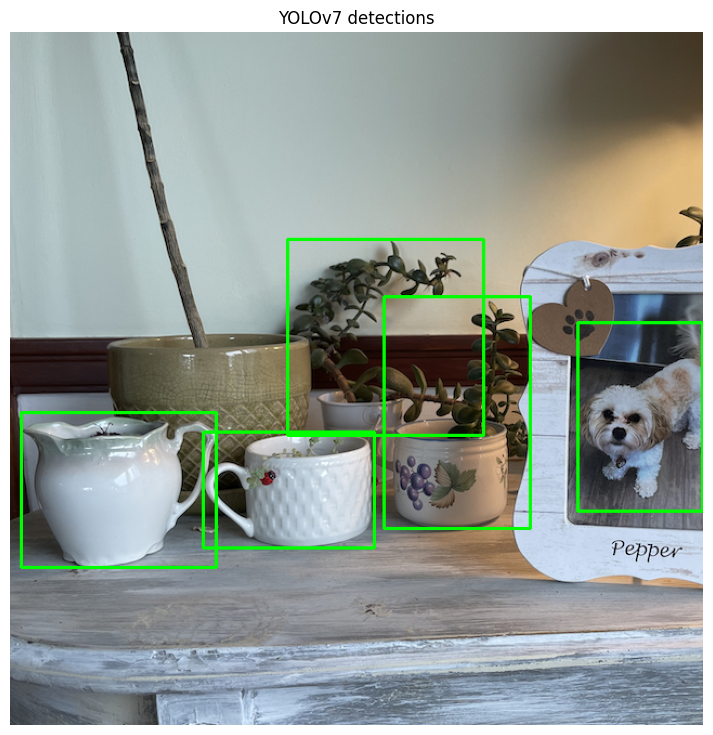


>>> Cloud (on-device) section skipped — no API token configured.
    Get one at workbench.aihub.qualcomm.com, then:
    !qai-hub configure --api_token YOUR_TOKEN
    detail: Failed to load client configuration file.

>>> Tutorial complete. Outputs in: /content/qaihm_out


In [2]:
try:
    import qai_hub as hub
    devices = hub.get_devices()
    print(f"\n>>> Authenticated. {len(devices)} cloud devices available.")
    device = hub.Device("Samsung Galaxy S24 (Family)")

    sample = model.sample_inputs()
    nchw = to_nchw(sample[input_name])
    traced = torch.jit.trace(model, [nchw])
    cloud_inputs = {input_name: [nchw.numpy()]}

    cj = hub.submit_compile_job(model=traced, device=device,
                                input_specs=model.get_input_spec(),
                                options="--target_runtime tflite")
    target = cj.get_target_model(); print(">>> compiled:", cj.url)
    pj = hub.submit_profile_job(model=target, device=device); print(">>> profiling:", pj.url)
    ij = hub.submit_inference_job(model=target, device=device, inputs=cloud_inputs)
    out = ij.download_output_data()
    dev_logits = torch.from_numpy(np.asarray(list(out.values())[0][0]))
    print(">>> Top-5 from the REAL device:")
    for label, conf in top5(dev_logits): print(f"    {conf:6.2%}  {label}")
    target.download(os.path.join(OUT_DIR, "mobilenet_v2.tflite"))
    print(">>> saved compiled .tflite to", OUT_DIR)
except Exception as e:
    print("\n>>> Cloud (on-device) section skipped — no API token configured.")
    print("    Get one at workbench.aihub.qualcomm.com, then:")
    print("    !qai-hub configure --api_token YOUR_TOKEN")
    print("    detail:", (str(e).splitlines() or [type(e).__name__])[0])

print("\n>>> Tutorial complete. Outputs in:", OUT_DIR)